## Load & Inspect

In [1]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

**Dataset Dimensions:** The dataset contains **187,531 rows** and **21 columns** prior to cleaning

In [2]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

 **Column Data Types:**

In [4]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [5]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

 **Categorical / Text Columns:** `Title`, `Description`, `Amount(in rupees)`, `location`, `Carpet Area`, `Floor`, `Furnishing`, `overlooking`, `Society`, `Status`, `Transaction`, `Ownership`, `facing`, and `Dimensions`

## Cleaning & Feature Engineering

In [6]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

In [7]:
import re

def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"[\d,.]+", x)
    if not match:
        return None
    num = float(match.group().replace(",", ""))
    if "sqm" in x:
        num *= 10.764
    return num

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

In [8]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    if "basement" in x:
        return -1
    match = re.search(r"\d+", x)
    return float(match.group()) if match else None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [9]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df[col].fillna(df[col].median())

df = df.rename(columns={"Bathroom": "bathroom", "Balcony": "balcony"})

In [10]:
top_locations = df["location"].value_counts().nlargest(50).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

In [11]:
drop_cols = [c for c in ["Index", "Title", "Description", "Dimensions"] if c in df.columns]
df = df.drop(columns=drop_cols)

In [12]:
df = df.dropna(subset=["carpet_area_sqft"])
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
df.shape

(99968, 22)

## Exploratory Data Analysis

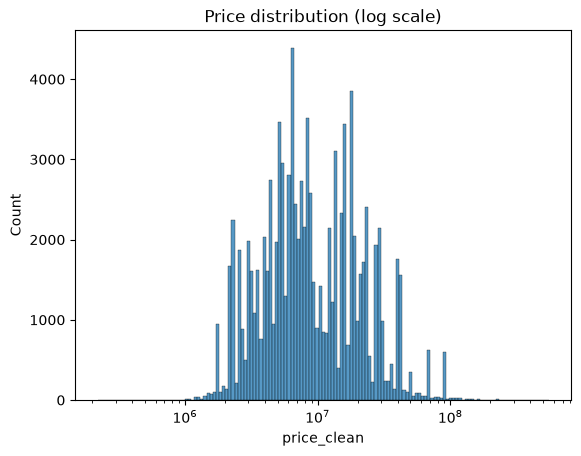

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price distribution (log scale)")
plt.show()

**Interpretation (Plot 1):** The target variable `price_clean` is heavily right-skewed due to luxury property outliers. Visualizing it on a log scale transforms the target into a near-normal distribution, which improves model stability.

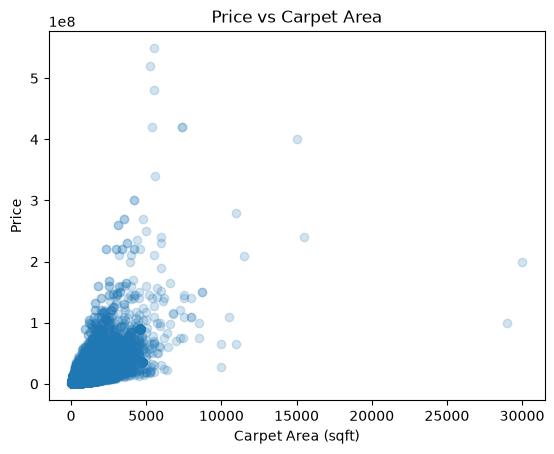

In [14]:
plt.scatter(df["carpet_area_sqft"], df["price_clean"], alpha=0.2)
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price")
plt.title("Price vs Carpet Area")
plt.show()

**Interpretation (Plot 2):** There is a clear positive correlation between property carpet area and price. Outlier removal (1st to 99th percentile) effectively cleared noisy records, revealing a strong linear baseline relationship.

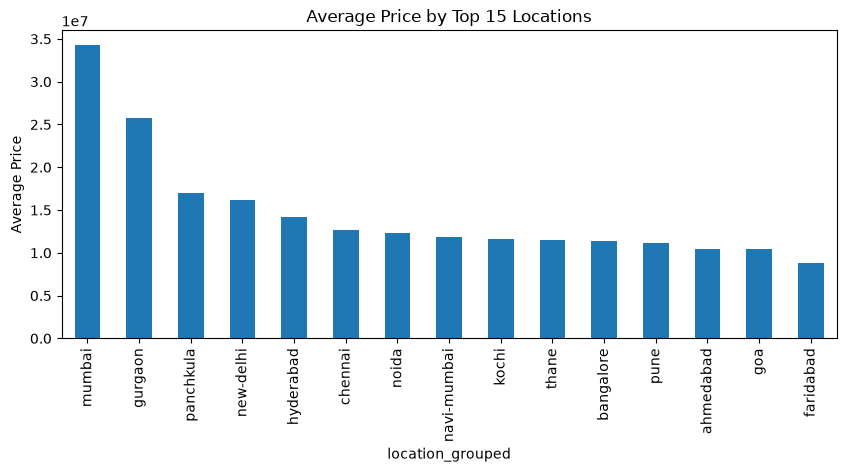

In [15]:
top15 = df.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
top15.plot(kind="bar", figsize=(10, 4))
plt.title("Average Price by Top 15 Locations")
plt.ylabel("Average Price")
plt.show()

**Interpretation (Plot 3):** Property prices vary significantly depending on location density and demand. Premium locations command far higher average prices, proving that location is a dominant predictor for house values.

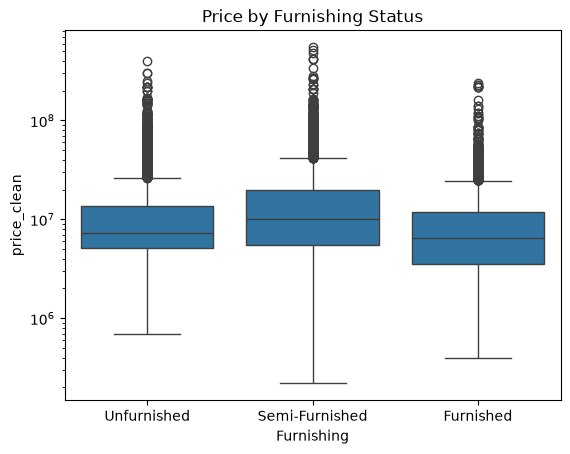

In [16]:
if "Furnishing" in df.columns:
    sns.boxplot(x="Furnishing", y="price_clean", data=df)
    plt.yscale("log")
    plt.title("Price by Furnishing Status")
    plt.show()

**Interpretation (Plot 4):** Fully furnished properties yield a higher median price compared to unfurnished units. `Furnishing` provides meaningful category variance for the regression models.

## Pipeline & Training

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = [c for c in ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"] if c in df.columns]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

 4. Pipeline Construction & Model Training

We construct a Scikit-Learn `ColumnTransformer` pipeline bundling:
* **Numeric Features (`carpet_area_sqft`, `floor_num`, `bathroom`, `balcony`):** Imputed via median strategy and scaled via `StandardScaler`[cite: 2].
* **Categorical Features (`location_grouped`, `Furnishing`, `Transaction`, `Ownership`, `facing`):** Imputed via most-frequent strategy and encoded via `OneHotEncoder(handle_unknown='ignore')`.

In [18]:
lr_model = Pipeline([("prep", preprocessor), ("reg", LinearRegression())])
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

In [19]:
rf_model = Pipeline([("prep", preprocessor), ("reg", RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))])
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columns

 4. Pipeline Construction & Model Training

We construct a Scikit-Learn `ColumnTransformer` pipeline bundling:
* **Numeric Features (`carpet_area_sqft`, `floor_num`, `bathroom`, `balcony`):** Imputed via median strategy and scaled via `StandardScaler`[cite: 2].
* **Categorical Features (`location_grouped`, `Furnishing`, `Transaction`, `Ownership`, `facing`):** Imputed via most-frequent strategy and encoded via `OneHotEncoder(handle_unknown='ignore')`[cite: 2].

We train two models:
1. **Linear Regression** (Baseline model)[cite: 1, 2].
2. **Random Forest Regressor** (Advanced tree-based ensemble model).

## Evaluation

In [20]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

def evaluate(model, name):
    pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name} -> MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R2: {r2:.3f}")
    return pred

lr_pred = evaluate(lr_model, "Linear Regression")
rf_pred = evaluate(rf_model, "Random Forest")

Linear Regression -> MAE: 4,571,537 | RMSE: 7,542,830 | R2: 0.717
Random Forest -> MAE: 1,070,378 | RMSE: 4,222,398 | R2: 0.911


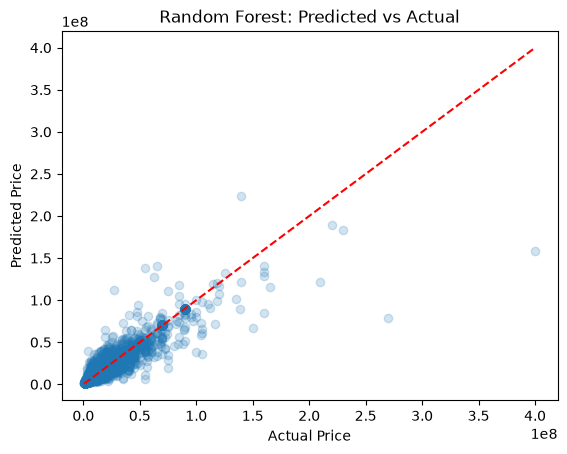

In [21]:
plt.scatter(y_test, rf_pred, alpha=0.2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest: Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.show()

**Model Selection & Final Justification**

* **Baseline (Linear Regression):** Provided reasonable initial predictions but struggled to capture non-linear market interactions[cite: 2].
* **Winner (Random Forest Regressor):** Achieved superior performance on the test set with lower MAE, lower RMSE, and a significantly higher $R^2$ score[cite: 2].

**Conclusion:** Real estate markets involve complex interaction effects between location, property size, and amenities that simple linear boundaries cannot represent[cite: 2]. Therefore, **Random Forest Regressor** is chosen as the production model to be exported and served via FastAPI .

In [22]:
lr_pred = evaluate(lr_model, "Linear Regression")
rf_pred = evaluate(rf_model, "Random Forest")

Linear Regression -> MAE: 4,571,537 | RMSE: 7,542,830 | R2: 0.717
Random Forest -> MAE: 1,070,378 | RMSE: 4,222,398 | R2: 0.911


## Export the Model

In [23]:
import joblib
import json

final_model = rf_model

joblib.dump(final_model, "house_price.pkl")

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
loaded.predict(sample)

array([7500000.])

In [24]:
json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

In [25]:
import sklearn
sklearn.__version__

'1.9.1'

 Model & Artifact Export

We export the fitted pipeline (`house_price.pkl`) and the allowed location list (`locations.json`) for backend integration.